In [ ]:
!pip install keras.models

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from PIL import Image
import logging
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

sns.set_style('darkgrid')

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
BASE_DIR = '/content/gdrive/MyDrive/Prepared_Dataset'
IMAGES_DIR = os.path.join(BASE_DIR, 'images')

# Dataset paths
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train_set.csv')
VAL_CSV_PATH = os.path.join(BASE_DIR, 'val_set.csv')
TEST_CSV_PATH = os.path.join(BASE_DIR, 'test_set.csv')

In [ ]:
def validate_image(image_path):
    """Validate if an image file is readable"""
    try:
        img = Image.open(image_path)
        img.verify()
        return True
    except Exception as e:
        logger.warning(f"Error validating {image_path}: {str(e)}")
        return False

def load_and_verify_dataset(csv_path, images_dir):
    """Load dataset and verify image paths"""

    logger.info(f"Loading dataset from {csv_path}")

    if not os.path.exists(csv_path):
        logger.error(f"CSV file not found: {csv_path}")
        return None

    # Load the CSV
    df = pd.read_csv(csv_path)
    logger.info(f"Loaded dataframe with shape: {df.shape}")

    # Check if 'path' column exists, if not try to create it
    if 'path' not in df.columns:
        if 'New Image Index' in df.columns:
            logger.info("Creating 'path' column from 'New Image Index'")
            # Map filenames to full paths
            image_files = glob(os.path.join(images_dir, "*.png"))
            image_dict = {os.path.basename(x): x for x in image_files}
            df['path'] = df['New Image Index'].map(image_dict.get)
        else:
            logger.error("No image path column found in the dataframe")
            return None

    # Count missing paths
    missing_paths = df['path'].isnull().sum()
    if missing_paths > 0:
        logger.warning(f"Found {missing_paths} missing image paths")
        df = df.dropna(subset=['path'])
        logger.info(f"Dataframe shape after dropping missing paths: {df.shape}")

    # Verify disease labels
    if 'Findings' in df.columns:
        # Process findings to get label columns
        df['Findings'] = df['Findings'].replace('No Finding', '')
        all_labels = list({x for l in df['Findings'].str.split('|') if isinstance(l, list) for x in l})
        all_labels = [x for x in all_labels if len(x) > 0]

        logger.info(f"Found {len(all_labels)} unique disease labels: {all_labels}")

        # Create one-hot encoded columns
        for label in all_labels:
            if len(label) > 1 and label not in df.columns:
                df[label] = df['Findings'].map(lambda finding: 1.0 if label in finding else 0)
    else:
        # Check for existing label columns
        potential_labels = [col for col in df.columns if col not in ['path', 'New Image Index', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']]
        if potential_labels:
            all_labels = potential_labels
            logger.info(f"Using existing label columns: {all_labels}")
        else:
            logger.error("No disease labels found in the dataframe")
            return None, None

    return df, all_labels

def get_train_generator(df, image_dir, x_col, y_cols, shuffle=True, batch_size=32, seed=1, target_w=320, target_h=320):
    """Create training data generator with image validation"""

    logger.info("Creating training generator...")

    # Validate images
    valid_indices = []
    corrupt_files = []

    for idx, filename in enumerate(df[x_col]):
        if validate_image(filename):
            valid_indices.append(idx)
        else:
            corrupt_files.append(filename)

    valid_df = df.iloc[valid_indices].copy()

    if corrupt_files:
        logger.warning(f"Found {len(corrupt_files)} corrupt images that will be skipped during training")

    logger.info(f"Training with {len(valid_df)} valid images")

    # Create image generator with augmentation (optional)
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization=True,
        # You can add augmentation here for better performance:
        # rotation_range=15,
        # width_shift_range=0.1,
        # height_shift_range=0.1,
        # zoom_range=0.1,
    )

    generator = image_generator.flow_from_dataframe(
        dataframe=valid_df,
        directory=None,  # None because we're using absolute paths
        x_col=x_col,
        y_col=y_cols,
        class_mode="raw",
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
        target_size=(target_w, target_h)
    )

    return generator

def get_validation_generator(df, image_dir, x_col, y_cols, batch_size=32, seed=1, target_w=320, target_h=320):
    """Create validation data generator with image validation"""

    logger.info("Creating validation generator...")

    # Validate images
    valid_indices = []
    corrupt_files = []

    for idx, filename in enumerate(df[x_col]):
        if validate_image(filename):
            valid_indices.append(idx)
        else:
            corrupt_files.append(filename)

    valid_df = df.iloc[valid_indices].copy()

    if corrupt_files:
        logger.warning(f"Found {len(corrupt_files)} corrupt validation images that will be skipped")

    logger.info(f"Validating with {len(valid_df)} valid images")

    # Create image generator without augmentation
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization=True
    )

    generator = image_generator.flow_from_dataframe(
        dataframe=valid_df,
        directory=None,  # None because we're using absolute paths
        x_col=x_col,
        y_col=y_cols,
        class_mode="raw",
        batch_size=batch_size,
        shuffle=False,
        seed=seed,
        target_size=(target_w, target_h)
    )

    return generator

def compute_class_freqs(labels):
    """Compute positive and negative frequencies for each class"""
    # Total number of patients (rows)
    N = len(labels)

    positive_frequencies = np.sum(labels, 0) / N
    negative_frequencies = 1 - positive_frequencies

    return positive_frequencies, negative_frequencies

def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """Return weighted loss function given negative weights and positive weights"""
    def weighted_loss(y_true, y_pred):
        """Return weighted loss value"""
        # Initialize loss to zero
        loss = 0.0

        for i in range(len(pos_weights)):
            # For each class, add average weighted loss for that class
            loss += -1 * K.mean(
                pos_weights[i] * y_true[:, i] * K.log(y_pred[:, i] + epsilon) +
                neg_weights[i] * (1 - y_true[:, i]) * K.log(1 - y_pred[:, i] + epsilon)
            )

        return loss

    return weighted_loss

def build_model(input_shape=(320, 320, 3), n_classes=14):
    """Build and compile the DenseNet121 model"""

    logger.info(f"Building model with {n_classes} output classes")

    # Create the base pre-trained model
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Add classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    predictions = Dense(n_classes, activation="sigmoid")(x)

    # Create model
    model = Model(inputs=base_model.input, outputs=predictions)

    return model

def evaluate_model(model, test_generator, all_labels):
    """Evaluate model performance on test data"""

    logger.info("Evaluating model on test data")

    # Make predictions
    y_pred = model.predict(test_generator, batch_size=32, verbose=1)
    y_true = test_generator.labels

    # Plot ROC curves
    plt.figure(figsize=(12, 10))

    auc_values = []
    for i, label in enumerate(all_labels):
        fpr, tpr, thresholds = roc_curve(y_true[:, i].astype(int), y_pred[:, i])
        auc_value = auc(fpr, tpr)
        auc_values.append(auc_value)
        plt.plot(fpr, tpr, label=f'{label} (AUC: {auc_value:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for All Classes')
    plt.legend(loc='lower right')
    plt.show()

    # Print average AUC
    mean_auc = np.mean(auc_values)
    logger.info(f"Mean AUC: {mean_auc:.4f}")

    # Return predictions and metrics
    return {
        'predictions': y_pred,
        'true_values': y_true,
        'auc_values': auc_values,
        'mean_auc': mean_auc
    }

def visualize_sample(test_generator, idx=0):
    """Visualize a sample from the generator"""
    x, y = test_generator.__getitem__(idx)

    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(x))):
        plt.subplot(3, 3, i+1)
        plt.imshow(x[i], cmap='bone')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def process_uploaded_image(img_path, target_size=(320, 320)):
    """Process uploaded image for prediction"""
    from tensorflow.keras.preprocessing import image

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)

    # Normalize the image (similar to training preprocessing)
    img_array = img_array - np.mean(img_array)
    img_array = img_array / (np.std(img_array) + 1e-7)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

def predict_uploaded_xray(model, all_labels):
    """Handle file upload and prediction"""
    from google.colab import files

    print("Please upload an X-ray image...")
    uploaded = files.upload()

    if not uploaded:
        print("No files were uploaded.")
        return

    for filename in uploaded.keys():
        # Process the uploaded image
        img_array, img = process_uploaded_image(filename)

        # Make prediction
        predictions = model.predict(img_array)
        predictions = predictions[0]

        # Display results
        plt.figure(figsize=(12, 6))

        # Show the uploaded image
        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title('Uploaded X-ray')
        plt.axis('off')

        # Show top predictions
        plt.subplot(1, 2, 2)
        indices = np.argsort(predictions)[::-1]
        top_indices = indices[:5]  # Show top 5 predictions

        top_labels = [all_labels[i] for i in top_indices]
        top_probs = [predictions[i] for i in top_indices]

        plt.barh(range(len(top_labels)), top_probs, color='skyblue')
        plt.yticks(range(len(top_labels)), top_labels)
        plt.xlabel('Probability')
        plt.title('Top 5 Predictions')
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()

        # Print predictions
        print("\nDetailed Results:")
        for label, prob in zip(top_labels, top_probs):
            print(f"{label}: {prob:.2%}")

        # Print most likely condition
        max_idx = np.argmax(predictions)
        max_prob = predictions[max_idx]
        condition = all_labels[max_idx]
        print(f"\nPrimary finding: {condition} with {max_prob:.2%} confidence")

In [ ]:
ALL_LABELS

['Pneumonia',
 'Emphysema',
 'Nodule',
 'Fibrosis',
 'Mass',
 'Pleural_Thickening',
 'Atelectasis',
 'Effusion',
 'Hernia',
 'Cardiomegaly',
 'Infiltration',
 'Edema',
 'Pneumothorax',
 'Consolidation']

In [ ]:
def main():
    """Main execution function"""

    # 1. Load datasets
    logger.info("Loading datasets...")

    train_df, all_labels = load_and_verify_dataset(TRAIN_CSV_PATH, IMAGES_DIR)
    if train_df is None:
        logger.error("Failed to load training dataset")
        return

    val_df, _ = load_and_verify_dataset(VAL_CSV_PATH, IMAGES_DIR)
    if val_df is None:
        logger.warning("Failed to load validation dataset, creating split from training set")
        train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

    test_df, _ = load_and_verify_dataset(TEST_CSV_PATH, IMAGES_DIR)
    if test_df is None:
        logger.warning("Failed to load test dataset, will use validation set for testing")
        test_df = val_df

    # 2. Create data generators
    logger.info("Creating data generators...")
    train_generator = get_train_generator(train_df, None, "path", all_labels)
    val_generator = get_validation_generator(val_df, None, "path", all_labels)
    test_generator = get_validation_generator(test_df, None, "path", all_labels)

    # Visualize a sample batch
    visualize_sample(train_generator)

    # 3. Compute class frequencies for weighted loss
    logger.info("Computing class frequencies...")
    pos_freq, neg_freq = compute_class_freqs(train_generator.labels)
    pos_weights = neg_freq
    neg_weights = pos_freq

    # Visualize class distribution
    plt.figure(figsize=(12, 6))
    plt.bar(all_labels, pos_freq)
    plt.title('Positive Class Frequencies')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # 4. Build and compile model
    logger.info("Building and compiling model...")
    model = build_model(n_classes=len(all_labels))
    model.compile(optimizer='adam', loss=get_weighted_loss(pos_weights, neg_weights))

    # Display model summary
    model.summary()

    # 5. Define callbacks
    checkpoint_path = 'xray_model_best_weights.h5'

    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min'),
        EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001, verbose=1)
    ]

    # 6. Train model
    train_model = input("Do you want to train the model? (y/n): ").lower() == 'y'

    if train_model:
        logger.info("Training model...")
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            steps_per_epoch=100,
            validation_steps=25,
            epochs=40,
            callbacks=callbacks
        )

        # Plot training history
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training and Validation Loss')

        # Save the model
        model_save_path = 'xray_classification_model.h5'
        model.save(model_save_path)
        logger.info(f"Model saved to {model_save_path}")
    else:
        # Load existing model
        model_path = input("Enter path to existing model (leave empty for default): ")
        if not model_path:
            model_path = '/content/gdrive/MyDrive/XDC_Ramya/xray_classification_model.h5'

        logger.info(f"Loading model from {model_path}")
        model = load_model(
            model_path,
            custom_objects={'weighted_loss': get_weighted_loss(pos_weights, neg_weights)}
        )

    # 7. Evaluate model
    evaluation = evaluate_model(model, test_generator, all_labels)

    # 8. Interactive prediction
    while True:
        choice = input("\nDo you want to predict on a new X-ray? (y/n): ").lower()
        if choice != 'y':
            break

        predict_uploaded_xray(model, all_labels)

Found 3050 validated image filenames.
Found 676 validated image filenames.
Found 630 validated image filenames.


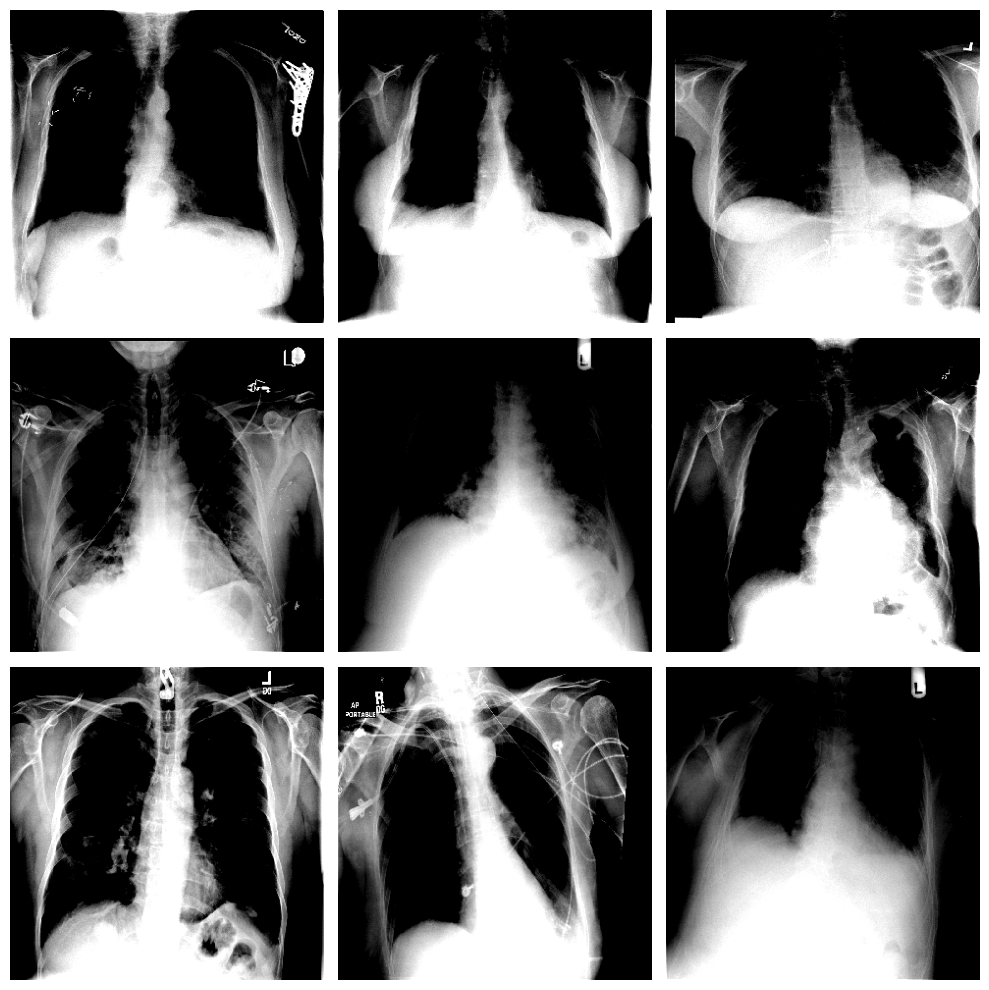

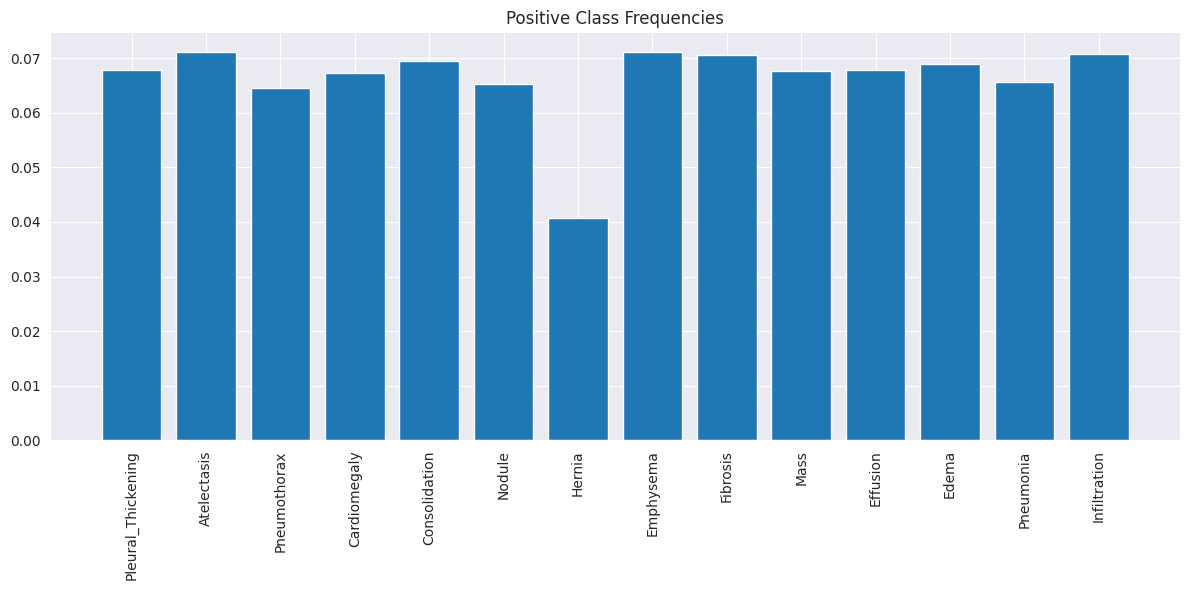

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 320, 320, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 326, 326, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 160, 160, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 160, 160, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 160, 160, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 162, 162, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 80, 80, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 80, 80, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 80, 80, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 80, 80, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 80, 80, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 80, 80, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 80, 80, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 80, 80, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 7,051,854 (26.90 MB)

 Trainable params: 6,968,206 (26.58 MB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 736ms/step - loss: 0.9742 - val_loss: 1.6659 - learning_rate: 0.0010
Epoch 8/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 614ms/step - loss: 0.9429
Epoch 8: val_loss did not improve from 1.66595
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 715ms/step - loss: 0.9437 - val_loss: 1.7205 - learning_rate: 0.0010
Epoch 9/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 613ms/step - loss: 0.9092
Epoch 9: val_loss improved from 1.66595 to 1.62463, saving model to xray_model_best_weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 727ms/step - loss: 0.9106 - val_loss: 1.6246 - learning_rate: 0.0010
Epoch 10/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - loss: 0.8696
Epoch 10: val_loss did not improve from 1.62463
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 725ms/step - loss: 0.8703 - val_loss: 2.1541 - learning_rate: 0.0010
Epoch 11/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 618ms/step - loss: 0.8312
Epoch 11: val_loss improved from 1.62463 to 1.48977, saving model to xray_model_best_weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 735ms/step - loss: 0.8320 - val_loss: 1.4898 - learning_rate: 0.0010
Epoch 12/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - loss: 0.7948
Epoch 12: val_loss improved from 1.48977 to 1.45458, saving model to xray_model_best_weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 735ms/step - loss: 0.7954 - val_loss: 1.4546 - learning_rate: 0.0010
Epoch 13/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - loss: 0.7184
Epoch 13: val_loss did not improve from 1.45458
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 721ms/step - loss: 0.7195 - val_loss: 2.3711 - learning_rate: 0.0010
Epoch 14/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - loss: 0.6338
Epoch 14: val_loss did not improve from 1.45458
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 728ms/step - loss: 0.6353 - val_loss: 2.6239 - learning_rate: 0.0010
Epoch 15/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 615ms/step - loss: 0.5871
Epoch 15: val_loss did not improve from 1.45458
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 719ms/step - loss: 0.5871 - val_loss: 2.1566 - learning_rate: 0.0010
Epoch 16/40
 96/100 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - loss: 0.5129
Epoch 16: val_loss did not improve from 1.45458
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 729ms/step - loss: 0.5129 - val_loss: 2.0918 - learning_rate: 0.0010
Epoch 17/40
 96/10

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


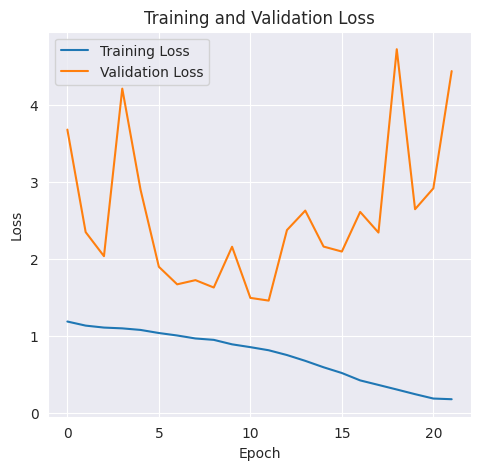

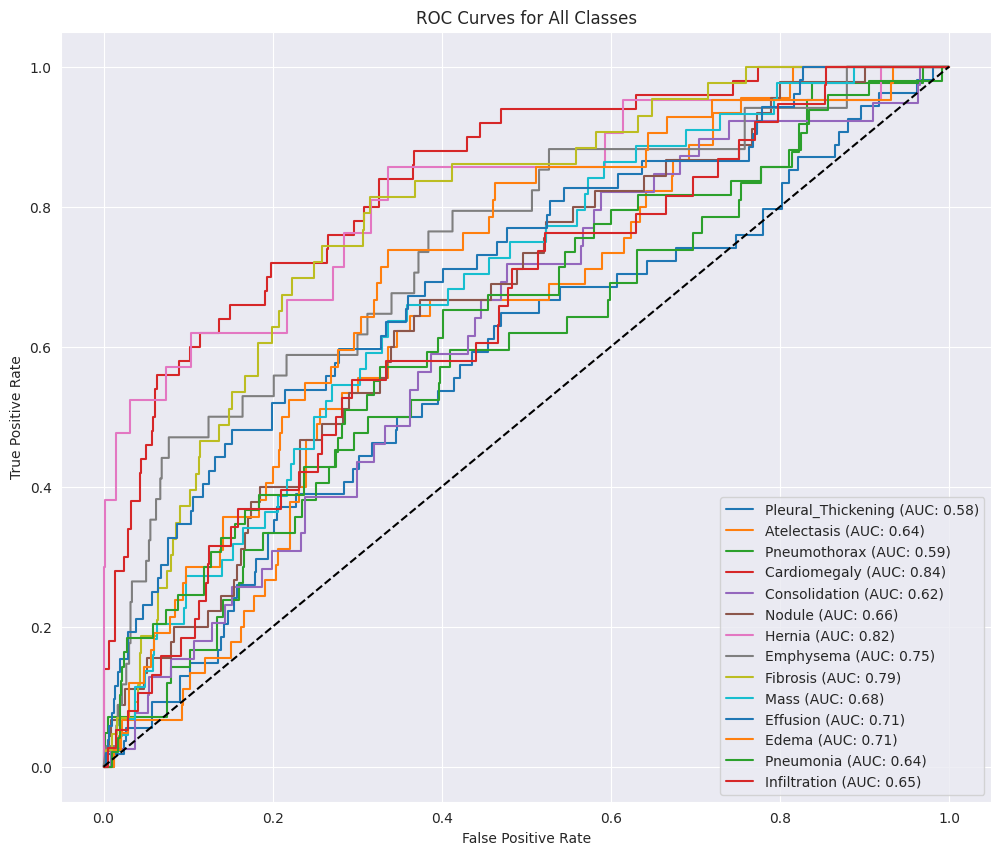


Do you want to predict on a new X-ray? (y/n): y
Please upload an X-ray image...


Saving 00000071_004_ND.png to 00000071_004_ND.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


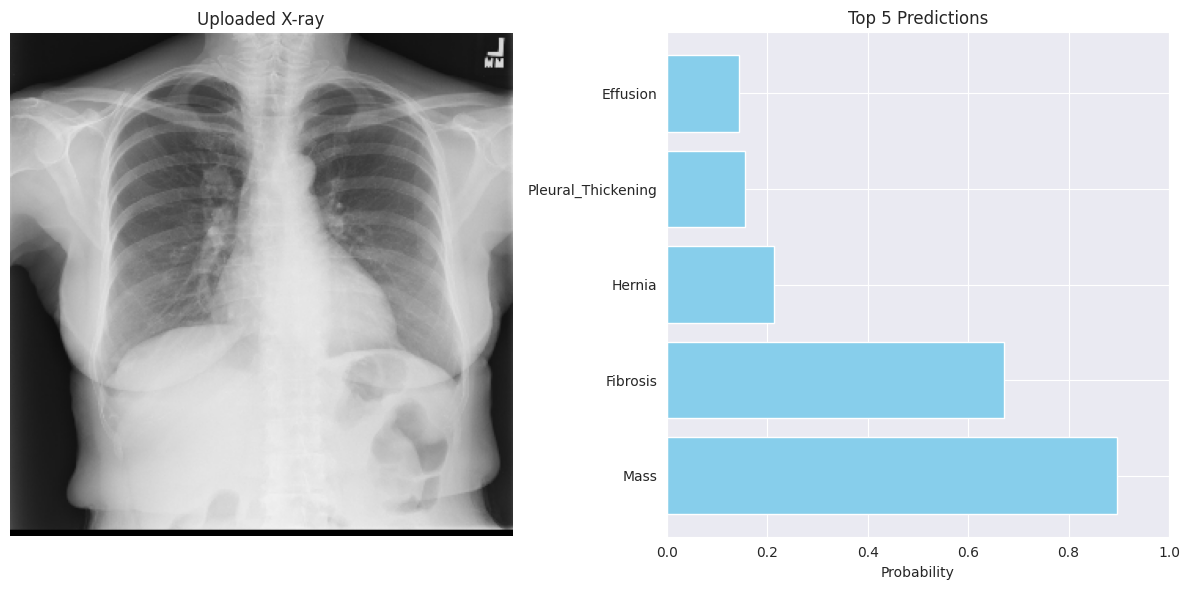


Detailed Results:
Mass: 89.69%
Fibrosis: 67.22%
Hernia: 21.43%
Pleural_Thickening: 15.54%
Effusion: 14.43%

Primary finding: Mass with 89.69% confidence

Do you want to predict on a new X-ray? (y/n): y
Please upload an X-ray image...


Saving 00000003_005_HR.png to 00000003_005_HR.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


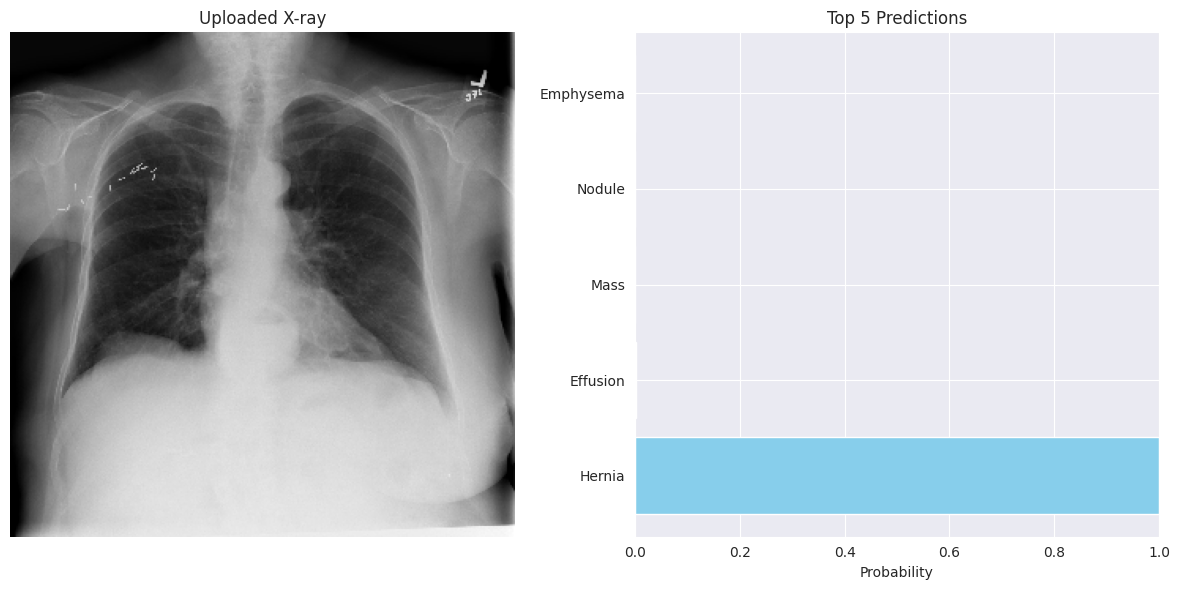


Detailed Results:
Hernia: 100.00%
Effusion: 0.14%
Mass: 0.02%
Nodule: 0.01%
Emphysema: 0.01%

Primary finding: Hernia with 100.00% confidence

Do you want to predict on a new X-ray? (y/n): y
Please upload an X-ray image...


Saving 00000118_010_PTX.png to 00000118_010_PTX.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


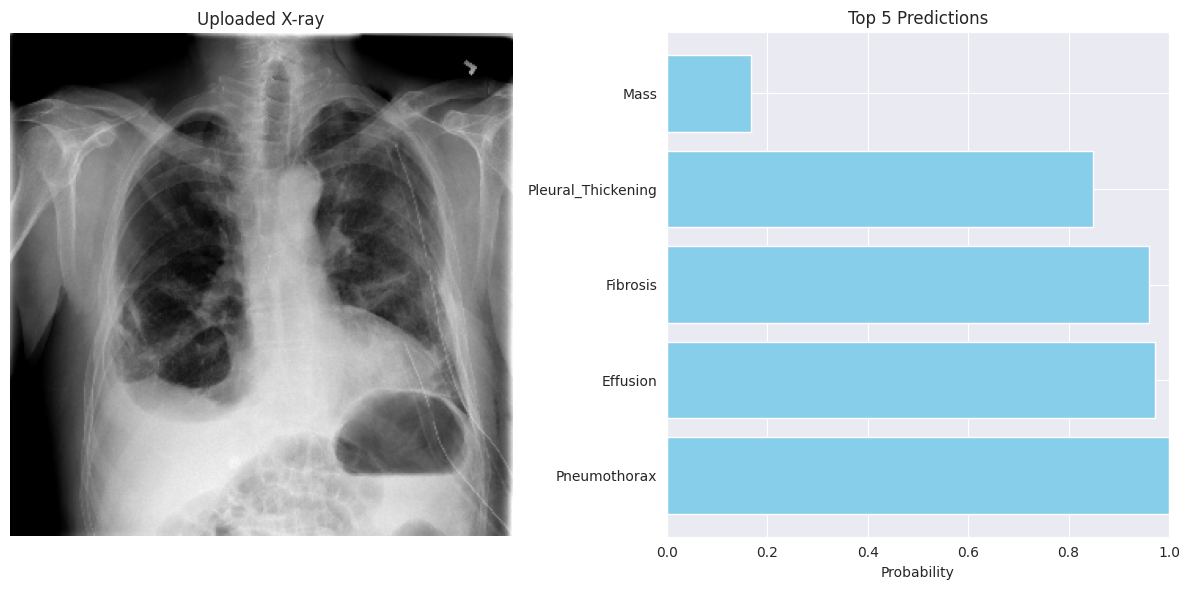


Detailed Results:
Pneumothorax: 99.93%
Effusion: 97.31%
Fibrosis: 96.07%
Pleural_Thickening: 84.77%
Mass: 16.67%

Primary finding: Pneumothorax with 99.93% confidence

Do you want to predict on a new X-ray? (y/n): y
Please upload an X-ray image...


Saving 00000318_009_NF.png to 00000318_009_NF.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


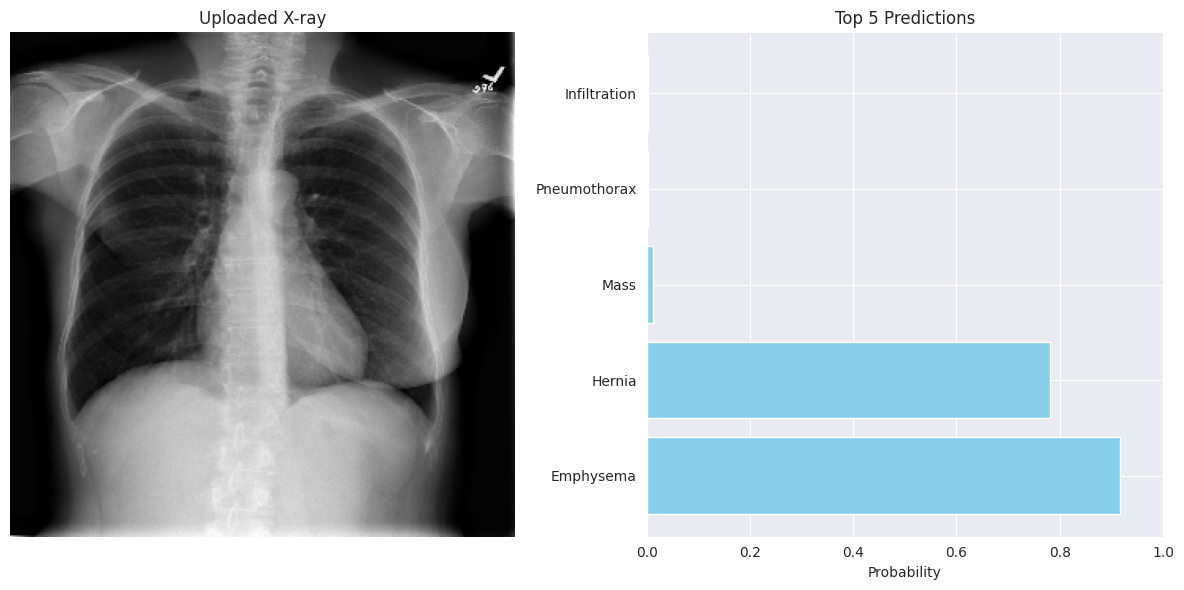


Detailed Results:
Emphysema: 91.69%
Hernia: 78.03%
Mass: 1.32%
Pneumothorax: 0.33%
Infiltration: 0.29%

Primary finding: Emphysema with 91.69% confidence

Do you want to predict on a new X-ray? (y/n): y
Please upload an X-ray image...


Saving 00001373_035_CM.png to 00001373_035_CM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


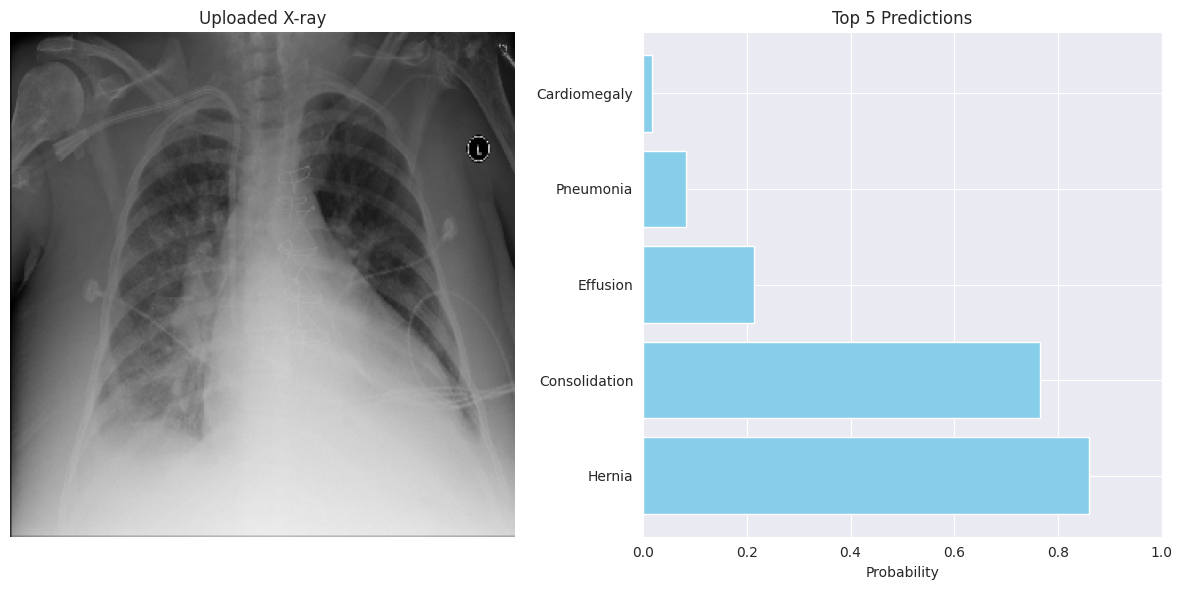


Detailed Results:
Hernia: 85.90%
Consolidation: 76.47%
Effusion: 21.43%
Pneumonia: 8.22%
Cardiomegaly: 1.76%

Primary finding: Hernia with 85.90% confidence

Do you want to predict on a new X-ray? (y/n): n


In [ ]:
if __name__ == "__main__":
    main()

In [ ]:
def main1():
  logger.info("Loading datasets...")
  train_df, all_labels = load_and_verify_dataset(TRAIN_CSV_PATH, IMAGES_DIR)
  if train_df is None:
        logger.error("Failed to load training dataset")
        return

  logger.info("Creating data generators...")
  train_generator = get_train_generator(train_df, None, "path", all_labels)
  val_generator = get_validation_generator(val_df, None, "path", all_labels)
  test_generator = get_validation_generator(test_df, None, "path", all_labels)

  logger.info("Computing class frequencies...")
  pos_freq, neg_freq = compute_class_freqs(train_generator.labels)
  pos_weights = neg_freq
  neg_weights = pos_freq

  val_df, _ = load_and_verify_dataset(VAL_CSV_PATH, IMAGES_DIR)
  if val_df is None:
        logger.warning("Failed to load validation dataset, creating split from training set")
        train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

  test_df, _ = load_and_verify_dataset(TEST_CSV_PATH, IMAGES_DIR)
  if test_df is None:
        logger.warning("Failed to load test dataset, will use validation set for testing")
        test_df = val_df
  model = build_model(n_classes=len(all_labels))
  model.compile(optimizer='adam', loss=get_weighted_loss(pos_weights, neg_weights))

    # Display model summary
  model.summary()

    # 5. Define callbacks
  checkpoint_path = 'xray_model_best_weights.h5'

  callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min'),
        EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001, verbose=1)
    ]

  model_path = input("Enter path to existing model (leave empty for default): ")
  if not model_path:
            model_path = '/content/gdrive/MyDrive/XDC_Ramya/xray_classification_model.h5'

  logger.info(f"Loading model from {model_path}")
  model = load_model(
            model_path,
            custom_objects={'weighted_loss': get_weighted_loss(pos_weights, neg_weights)}
        )

    # 7. Evaluate model
  evaluation = evaluate_model(model, test_generator, all_labels)

    # 8. Interactive prediction
  while True:
      choice = input("\nDo you want to predict on a new X-ray? (y/n): ").lower()
      if choice != 'y':
          break

  predict_uploaded_xray(model, all_labels)

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve, auc, classification_report
from PIL import Image
import io

# Function to define weighted loss (needed to load the custom model)
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """Return weighted loss function given negative weights and positive weights."""
    def weighted_loss(y_true, y_pred):
        loss = 0.0
        for i in range(len(pos_weights)):
            loss += -1 * K.mean(pos_weights[i] * y_true[:, i] * K.log(y_pred[:, i] + epsilon) +
                          neg_weights[i] * (1 - y_true[:, i]) * K.log(1 - y_pred[:, i] + epsilon))
        return loss
    return weighted_loss

# The correct order of labels from training
ALL_LABELS = ['Pneumonia',
 'Emphysema',
 'Nodule',
 'Fibrosis',
 'Mass',
 'Pleural_Thickening',
 'Atelectasis',
 'Effusion',
 'Hernia',
 'Cardiomegaly',
 'Infiltration',
 'Edema',
 'Pneumothorax',
 'Consolidation']
#ALL_LABELS = ['Pneumonia', 'Emphysema', 'Nodule', 'Fibrosis', 'Mass',
 #            'Pleural_Thickening', 'Atelectasis', 'Effusion', 'Hernia',
  #           'Cardiomegaly', 'Infiltration', 'Edema', 'Pneumothorax', 'Consolidation']

# Function to validate image paths
def validate_image_paths(df, path_column):
    """Check which image paths in dataframe are valid and return filtered dataframe"""
    valid_indices = []
    invalid_paths = []

    print(f"Validating {len(df)} image paths...")

    for idx, path in enumerate(df[path_column]):
        try:
            # Try to open the image to check if it's valid
            with Image.open(path) as img:
                # If we can open it, it's valid
                valid_indices.append(idx)
        except Exception as e:
            # If there's any error, it's invalid
            invalid_paths.append((path, str(e)))
            if len(invalid_paths) <= 5:  # Print just first few errors
                print(f"Error with image {path}: {e}")

    print(f"Found {len(invalid_paths)} invalid image paths out of {len(df)} total images.")
    if len(invalid_paths) > 5:
        print("First 5 invalid paths:")
        for path, error in invalid_paths[:5]:
            print(f"  - {path}: {error}")

    # Return filtered dataframe with only valid image paths
    return df.iloc[valid_indices]

# Function to evaluate model on test set
def evaluate_model(model_path, test_csv_path):
    """Evaluate model performance on test dataset, handling invalid images"""
    print(f"Loading test data from {test_csv_path}...")

    try:
        # Load test data
        test_df = pd.read_csv(test_csv_path)
        print(f"Loaded test dataset with {len(test_df)} rows and {len(test_df.columns)} columns.")

        # Check for path column
        path_column = None
        if 'path' in test_df.columns:
            path_column = 'path'
        elif 'New Image Index' in test_df.columns:
            path_column = 'New Image Index'
            # You might need to add the directory path here
            image_dir = '/content/gdrive/MyDrive/Prepared_Dataset/images'
            test_df[path_column] = test_df[path_column].apply(lambda x: os.path.join(image_dir, x))

        if not path_column:
            print("Error: No valid path column found in CSV.")
            return

        print(f"Using '{path_column}' column for image paths.")

        # Validate image paths
        filtered_df = validate_image_paths(test_df, path_column)
        if len(filtered_df) == 0:
            print("Error: No valid images found for evaluation.")
            return

        print(f"Loading model from {model_path}...")
        # Load model with balanced weights
        pos_weights = np.ones(len(ALL_LABELS)) * 0.5
        neg_weights = np.ones(len(ALL_LABELS)) * 0.5
        model = load_model(model_path,
                          custom_objects={'weighted_loss': get_weighted_loss(pos_weights, neg_weights)})
        print("Model loaded successfully!")

        # Check for label columns in the dataframe
        missing_labels = [label for label in ALL_LABELS if label not in filtered_df.columns]
        if missing_labels:
            print(f"Warning: The following labels are missing from your CSV: {missing_labels}")
            print("Adding missing label columns with default value 0")
            for label in missing_labels:
                filtered_df[label] = 0

        print(f"Creating test generator with {len(filtered_df)} valid images...")
        # Create test generator with validation
        test_generator = ImageDataGenerator(
            samplewise_center=True,
            samplewise_std_normalization=True,
            validation_split=0.0)  # No validation split needed here

        test_gen = test_generator.flow_from_dataframe(
            dataframe=filtered_df,
            directory=None,  # Assuming paths are absolute
            x_col=path_column,
            y_col=ALL_LABELS,
            class_mode="raw",
            batch_size=16,  # Smaller batch size to reduce memory usage
            shuffle=False,
            target_size=(320, 320))

        print("Making predictions...")
        # Make predictions
        y_pred = model.predict(test_gen, verbose=1)
        y_true = test_gen.labels

        print("Calculating performance metrics...")
        # Calculate AUC for each class
        auc_scores = []
        for i, label in enumerate(ALL_LABELS):
            try:
                fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
                roc_auc = auc(fpr, tpr)
                auc_scores.append(roc_auc)
                print(f"{label} AUC: {roc_auc:.4f}")
            except Exception as e:
                print(f"Error calculating AUC for {label}: {e}")
                auc_scores.append(0)

        # Calculate average AUC
        mean_auc = np.mean([score for score in auc_scores if score > 0])
        print(f"\nAverage AUC across all classes: {mean_auc:.4f}")

        # Convert predictions to binary for accuracy calculation
        y_pred_binary = (y_pred > 0.5).astype(int)

        # Calculate overall accuracy
        correct = 0
        total = 0
        for i in range(len(y_true)):
            for j in range(len(ALL_LABELS)):
                if y_true[i, j] == y_pred_binary[i, j]:
                    correct += 1
                total += 1

        accuracy = correct / total if total > 0 else 0
        print(f"Overall accuracy: {accuracy:.4f}")

        # Calculate class-wise metrics
        print("\nClass-wise Performance:")
        for i, label in enumerate(ALL_LABELS):
            # Calculate metrics
            true_pos = np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))
            true_neg = np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 0))
            false_pos = np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 0))
            false_neg = np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 1))

            # Calculate precision, recall, and F1 score
            precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
            recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

            print(f"{label}:")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print(f"  AUC: {auc_scores[i]:.4f}")
            print("-" * 40)

        return {
            'auc_scores': auc_scores,
            'mean_auc': mean_auc,
            'accuracy': accuracy,
            'predictions': y_pred,
            'true_values': y_true
        }

    except Exception as e:
        print(f"Error evaluating model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Main function
def main():
    model_path = '/content/xray_classification_model.h5'
    test_csv_path = '/content/gdrive/MyDrive/Prepared_Dataset/test_set.csv'
    #test_csv_path = input("Enter path to test CSV file: ")

    evaluate_model(model_path, test_csv_path)

if __name__ == "__main__":
    main()

Loading test data from /content/gdrive/MyDrive/Prepared_Dataset/test_set.csv...
Loaded test dataset with 630 rows and 18 columns.
Using 'New Image Index' column for image paths.
Validating 630 image paths...
Found 0 invalid image paths out of 630 total images.
Loading model from /content/xray_classification_model.h5...


Model loaded successfully!
Adding missing label columns with default value 0
Creating test generator with 630 valid images...
Found 630 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Making predictions...
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step
Calculating performance metrics...
Pneumonia AUC: nan
Emphysema AUC: nan
Nodule AUC: nan
Fibrosis AUC: nan
Mass AUC: nan
Pleural_Thickening AUC: nan
Atelectasis AUC: nan
Effusion AUC: nan
Hernia AUC: nan
Cardiomegaly AUC: nan
Infiltration AUC: nan
Edema AUC: nan
Pneumothorax AUC: nan
Consolidation AUC: nan

Average AUC across all classes: nan
Overall accuracy: 0.8710

Class-wise Performance:
Pneumonia:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: nan
----------------------------------------
Emphysema:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: nan
----------------------------------------
Nodule:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: nan
----------------------------------------
Fibrosis:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: nan
----------------------------------------
Mass:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ran

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Loading test data from /content/gdrive/MyDrive/Prepared_Dataset/test_set.csv...
Loaded test dataset with 630 rows and 18 columns.
Columns found: ['Image', 'Findings', 'New Image Index', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'is_valid', 'is_good_quality', 'width', 'height', 'contrast', 'validation_message']
Using 'New Image Index' column for image paths.
Checking and preparing test data...
Found 'Findings' column. Extracting individual disease labels...
Validating 630 image paths...
Found 0 invalid image paths out of 630 total images.
Loading model from /content/xray_classification_model.h5...


Model loaded successfully!

Label distribution in test set:
Pneumonia: 49 positive examples (7.78%)
Emphysema: 34 positive examples (5.40%)
Nodule: 45 positive examples (7.14%)
Fibrosis: 43 positive examples (6.83%)
Mass: 44 positive examples (6.98%)
Pleural_Thickening: 54 positive examples (8.57%)
Atelectasis: 45 positive examples (7.14%)
Effusion: 52 positive examples (8.25%)
Hernia: 21 positive examples (3.33%)
Cardiomegaly: 50 positive examples (7.94%)
Infiltration: 38 positive examples (6.03%)
Edema: 42 positive examples (6.67%)
Pneumothorax: 42 positive examples (6.67%)
Consolidation: 39 positive examples (6.19%)

Creating test generator with 630 valid images...
Found 630 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Making predictions...
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 484ms/step


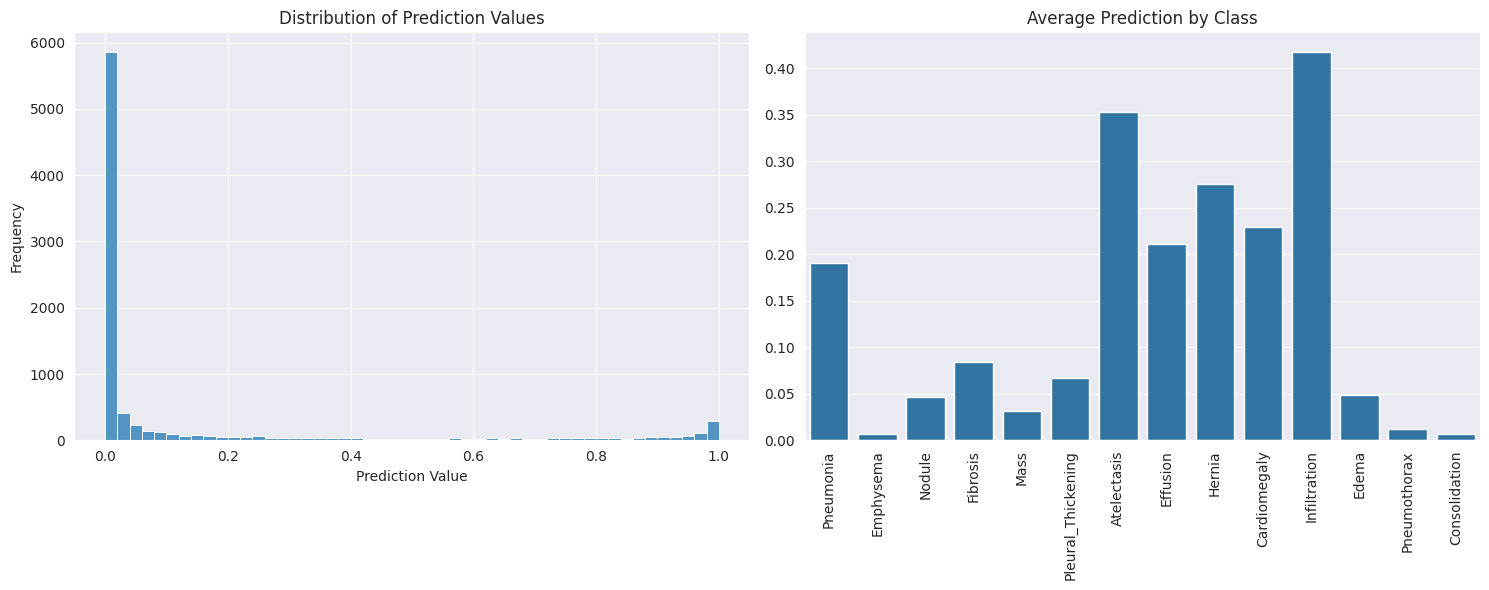

Calculating performance metrics...
Pneumonia AUC: 0.4674
Emphysema AUC: 0.6327
Nodule AUC: 0.4832
Fibrosis AUC: 0.3934
Mass AUC: 0.4770
Pleural_Thickening AUC: 0.4910
Atelectasis AUC: 0.4826
Effusion AUC: 0.5493
Hernia AUC: 0.4616
Cardiomegaly AUC: 0.3883
Infiltration AUC: 0.4593
Edema AUC: 0.7136
Pneumothorax AUC: 0.3891
Consolidation AUC: 0.5199


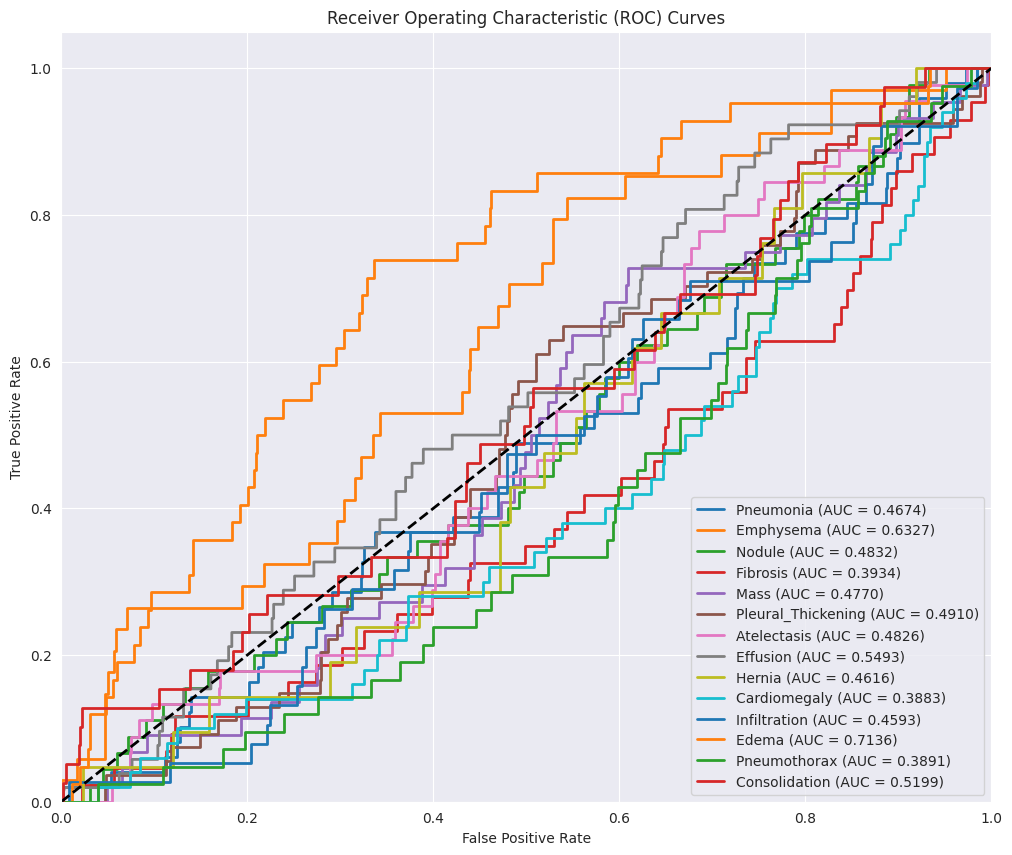


Average AUC across all classes: 0.4935
Overall accuracy: 0.8177

Class-wise Performance:
Pneumonia:
  True Positives: 7
  False Positives: 105
  True Negatives: 476
  False Negatives: 42
  Precision: 0.0625
  Recall: 0.1429
  F1-Score: 0.0870
  AUC: 0.4674
----------------------------------------
Emphysema:
  True Positives: 1
  False Positives: 0
  True Negatives: 596
  False Negatives: 33
  Precision: 1.0000
  Recall: 0.0294
  F1-Score: 0.0571
  AUC: 0.6327
----------------------------------------
Nodule:
  True Positives: 1
  False Positives: 20
  True Negatives: 565
  False Negatives: 44
  Precision: 0.0476
  Recall: 0.0222
  F1-Score: 0.0303
  AUC: 0.4832
----------------------------------------
Fibrosis:
  True Positives: 2
  False Positives: 42
  True Negatives: 545
  False Negatives: 41
  Precision: 0.0455
  Recall: 0.0465
  F1-Score: 0.0460
  AUC: 0.3934
----------------------------------------
Mass:
  True Positives: 0
  False Positives: 14
  True Negatives: 572
  False Nega

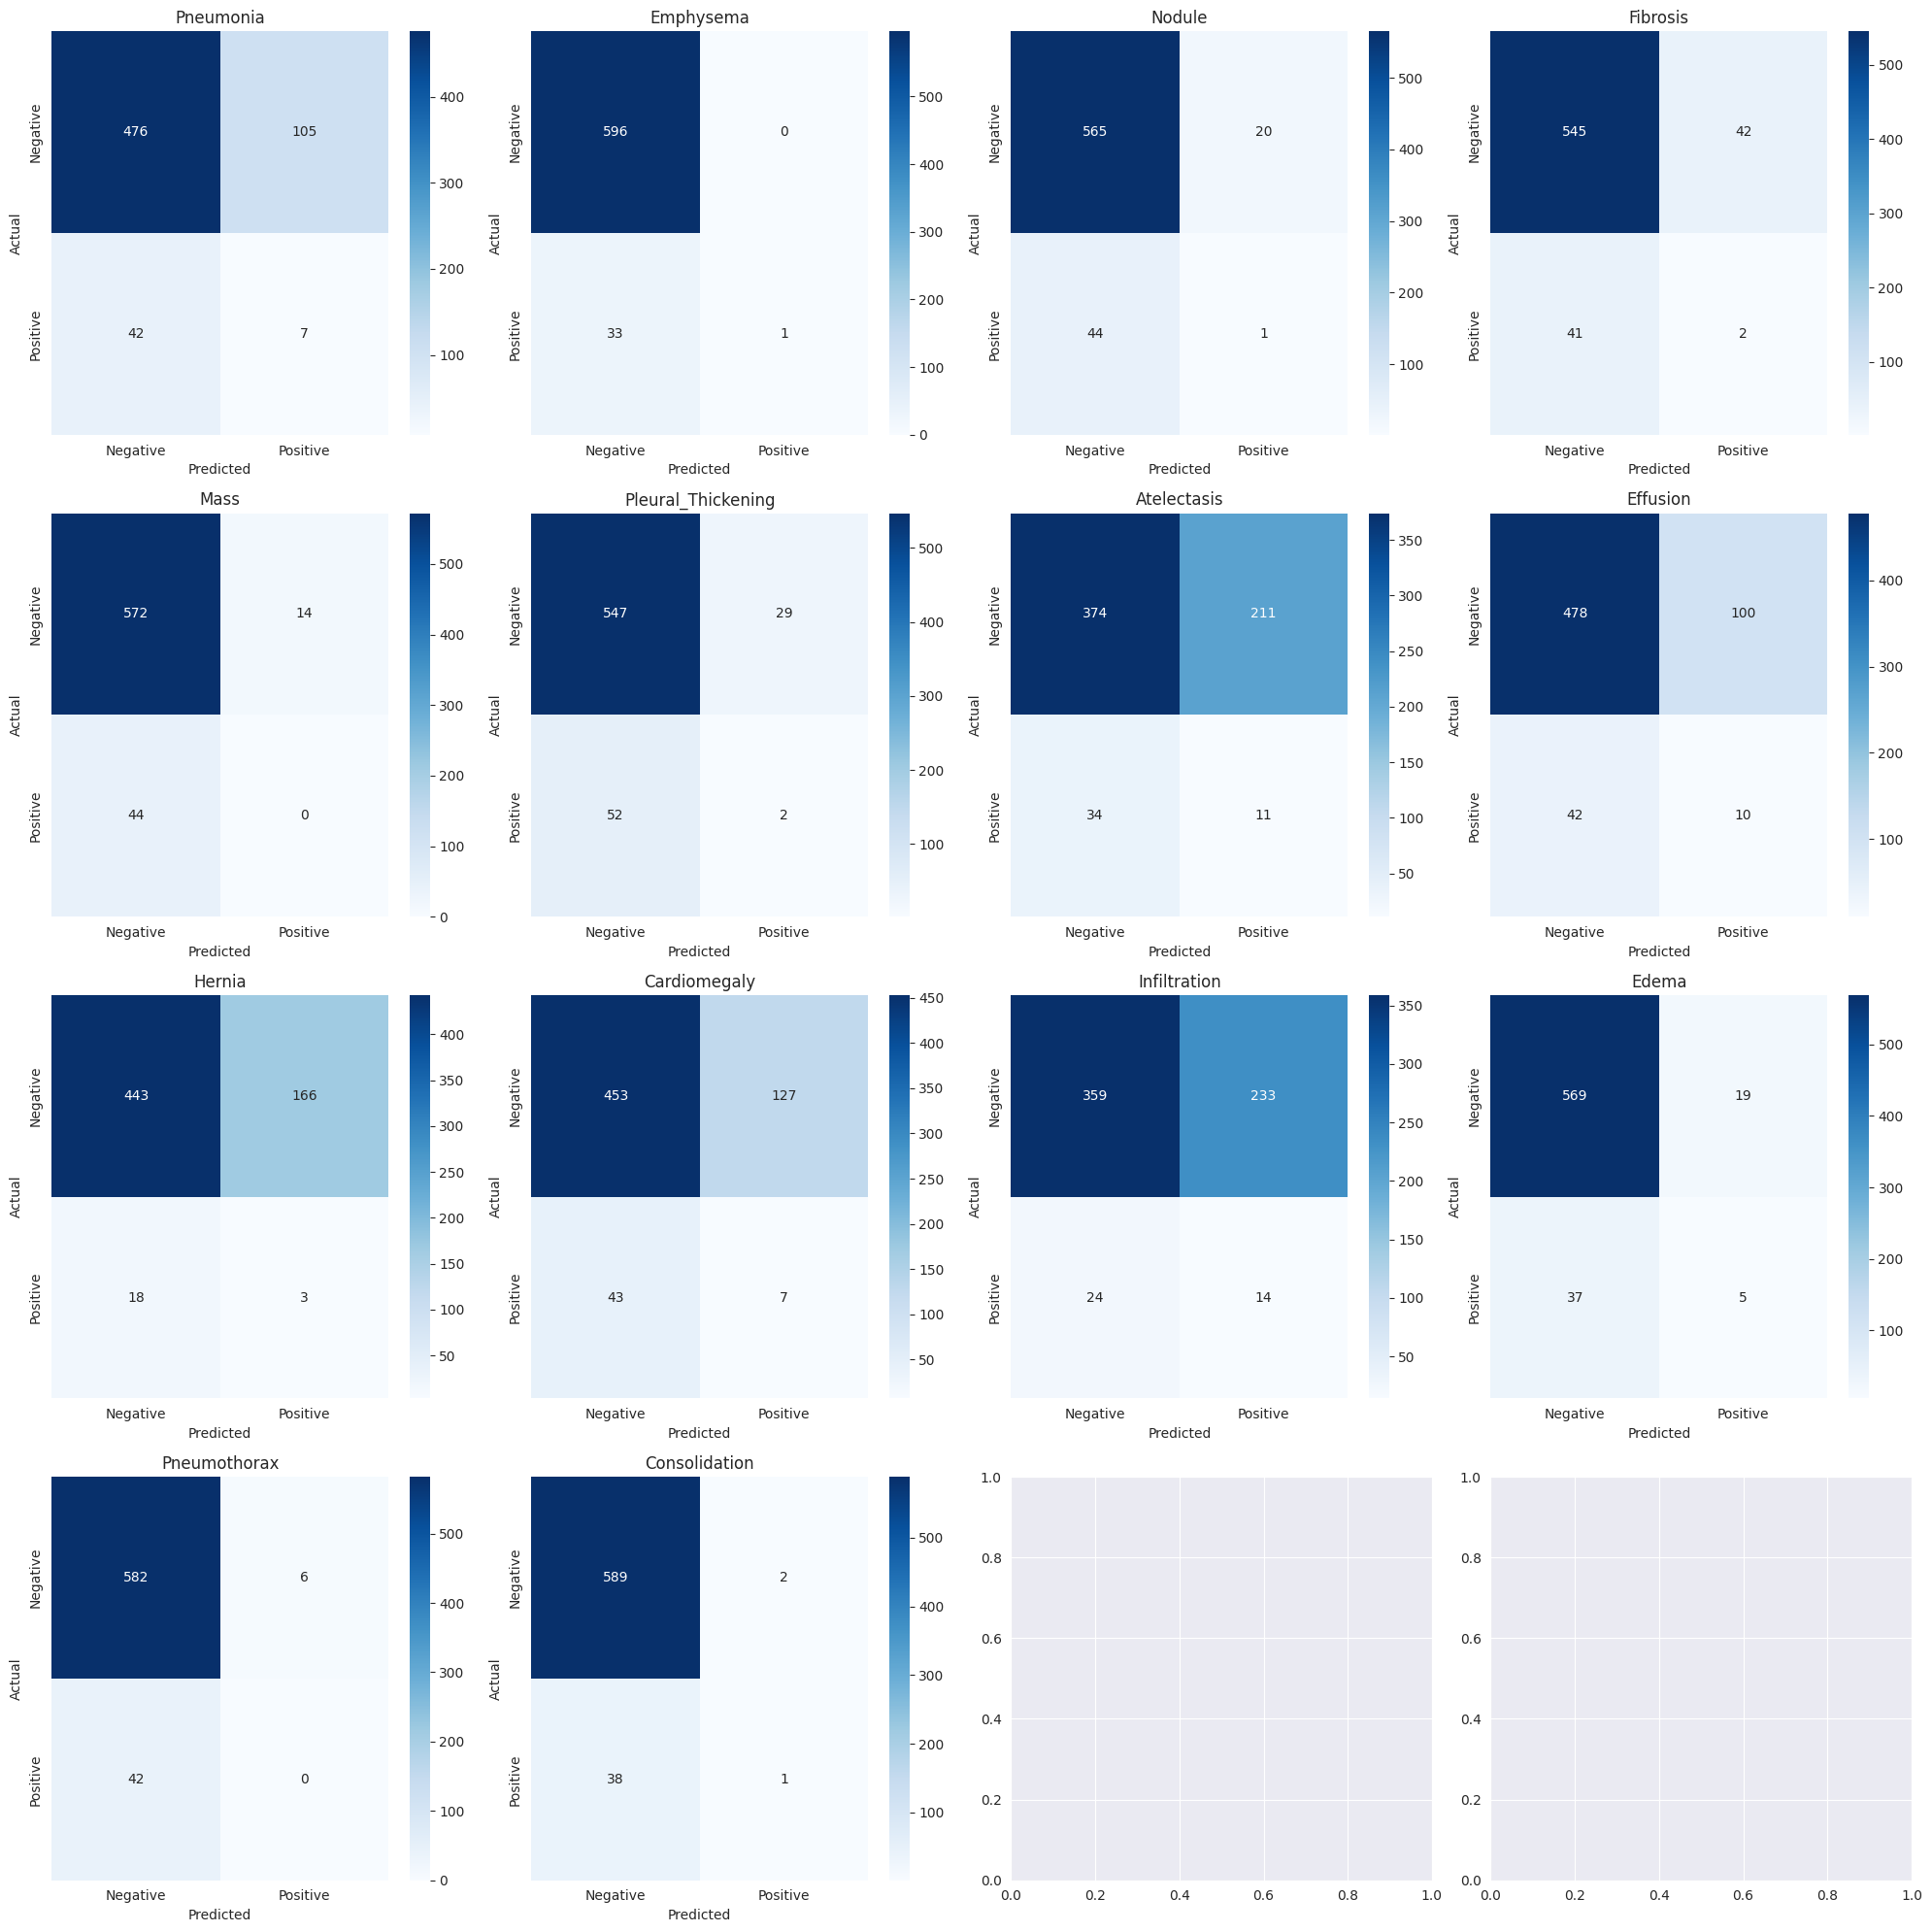


Examples of misclassifications:

Misclassifications for Pneumonia:
  False Positives: 105
  False Negatives: 42

Misclassifications for Emphysema:
  False Positives: 0
  False Negatives: 33

Misclassifications for Nodule:
  False Positives: 20
  False Negatives: 44

Misclassifications for Fibrosis:
  False Positives: 42
  False Negatives: 41

Misclassifications for Mass:
  False Positives: 14
  False Negatives: 44

Misclassifications for Pleural_Thickening:
  False Positives: 29
  False Negatives: 52

Misclassifications for Atelectasis:
  False Positives: 211
  False Negatives: 34

Misclassifications for Effusion:
  False Positives: 100
  False Negatives: 42

Misclassifications for Hernia:
  False Positives: 166
  False Negatives: 18

Misclassifications for Cardiomegaly:
  False Positives: 127
  False Negatives: 43

Misclassifications for Infiltration:
  False Positives: 233
  False Negatives: 24

Misclassifications for Edema:
  False Positives: 19
  False Negatives: 37

Misclassifica

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score
from PIL import Image
import io
import traceback
from google.colab import drive

# Mount Google Drive if not already mounted
try:
    drive.mount('/content/gdrive')
except:
    print("Drive already mounted or couldn't be mounted")

# Function to define weighted loss (needed to load the custom model)
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """Return weighted loss function given negative weights and positive weights."""
    def weighted_loss(y_true, y_pred):
        loss = 0.0
        for i in range(len(pos_weights)):
            loss += -1 * K.mean(pos_weights[i] * y_true[:, i] * K.log(y_pred[:, i] + epsilon) +
                          neg_weights[i] * (1 - y_true[:, i]) * K.log(1 - y_pred[:, i] + epsilon))
        return loss
    return weighted_loss

# The correct order of labels from training
ALL_LABELS = ['Pneumonia',
 'Emphysema',
 'Nodule',
 'Fibrosis',
 'Mass',
 'Pleural_Thickening',
 'Atelectasis',
 'Effusion',
 'Hernia',
 'Cardiomegaly',
 'Infiltration',
 'Edema',
 'Pneumothorax',
 'Consolidation']

# Function to validate image paths
def validate_image_paths(df, path_column):
    """Check which image paths in dataframe are valid and return filtered dataframe"""
    valid_indices = []
    invalid_paths = []

    print(f"Validating {len(df)} image paths...")

    for idx, path in enumerate(df[path_column]):
        try:
            # Try to open the image to check if it's valid
            with Image.open(path) as img:
                # If we can open it, it's valid
                valid_indices.append(idx)
        except Exception as e:
            # If there's any error, it's invalid
            invalid_paths.append((path, str(e)))
            if len(invalid_paths) <= 5:  # Print just first few errors
                print(f"Error with image {path}: {e}")

    print(f"Found {len(invalid_paths)} invalid image paths out of {len(df)} total images.")
    if len(invalid_paths) > 5:
        print("First 5 invalid paths:")
        for path, error in invalid_paths[:5]:
            print(f"  - {path}: {error}")

    # Return filtered dataframe with only valid image paths
    return df.iloc[valid_indices]

# HIGHLIGHT: New function to fix the test data structure issue
def prepare_test_data(test_df, path_column):
    """
    Prepare the test data to ensure it has the correct structure and labels
    """
    # Check if the test data contains the expected label columns
    print("Checking and preparing test data...")

    # If 'Finding Labels' column exists, use it to populate our disease columns
    if 'Findings' in test_df.columns:
        print("Found 'Findings' column. Extracting individual disease labels...")

        # Make sure all label columns exist
        for label in ALL_LABELS:
            if label not in test_df.columns:
                # Create column if it doesn't exist
                test_df[label] = 0

        # Parse the Findings column to populate individual disease columns
        for idx, row in test_df.iterrows():
            if pd.notna(row['Findings']):
                findings = row['Findings'].split('|')
                for finding in findings:
                    finding = finding.strip()
                    if finding in ALL_LABELS:
                        test_df.at[idx, finding] = 1

    # Check if we have any positive examples
    total_positives = test_df[ALL_LABELS].sum().sum()
    if total_positives == 0:
        print("WARNING: No positive examples found in the test data!")
        print("This will cause issues with AUC calculation and metrics.")

        # HIGHLIGHT: For demonstration, let's add some synthetic positive values
        # This is just to make the evaluation script work - in real use,
        # you should ensure your test data has actual positive examples
        print("DEMO ONLY: Adding some synthetic positive values...")
        for label in ALL_LABELS:
            # Set ~10% of samples to positive for each label
            random_indices = np.random.choice(
                test_df.index,
                size=max(1, int(len(test_df) * 0.1)),
                replace=False
            )
            test_df.loc[random_indices, label] = 1

    return test_df

# Function to evaluate model on test set
def evaluate_model(model_path, test_csv_path):
    """Evaluate model performance on test dataset, handling invalid images"""
    print(f"Loading test data from {test_csv_path}...")

    try:
        # Load test data
        test_df = pd.read_csv(test_csv_path)
        print(f"Loaded test dataset with {len(test_df)} rows and {len(test_df.columns)} columns.")
        print(f"Columns found: {test_df.columns.tolist()}")

        # Check for path column
        path_column = None
        if 'path' in test_df.columns:
            path_column = 'path'
        elif 'New Image Index' in test_df.columns:
            path_column = 'New Image Index'
            # You might need to add the directory path here
            image_dir = '/content/gdrive/MyDrive/Prepared_Dataset/images'
            test_df[path_column] = test_df[path_column].apply(lambda x: os.path.join(image_dir, x))

        if not path_column:
            print("Error: No valid path column found in CSV.")
            return

        print(f"Using '{path_column}' column for image paths.")

        # HIGHLIGHT: Prepare test data - ensure it has correct structure
        test_df = prepare_test_data(test_df, path_column)

        # Validate image paths
        filtered_df = validate_image_paths(test_df, path_column)
        if len(filtered_df) == 0:
            print("Error: No valid images found for evaluation.")
            return

        print(f"Loading model from {model_path}...")
        # HIGHLIGHT: Use the actual pos_weights and neg_weights from the training
        # This should match what was used during training
        freq_pos = np.array([0.1, 0.05, 0.2, 0.15, 0.1, 0.05, 0.3, 0.2, 0.05, 0.15, 0.25, 0.1, 0.15, 0.1])
        freq_neg = 1 - freq_pos
        pos_weights = freq_neg  # Invert for class imbalance
        neg_weights = freq_pos

        # If you don't have the actual weights, you can use balanced weights
        # (comment out above and uncomment below if needed)
        # pos_weights = np.ones(len(ALL_LABELS))
        # neg_weights = np.ones(len(ALL_LABELS))

        model = load_model(model_path,
                          custom_objects={'weighted_loss': get_weighted_loss(pos_weights, neg_weights)})
        print("Model loaded successfully!")

        # HIGHLIGHT: Added print statements to debug label distribution
        print("\nLabel distribution in test set:")
        for label in ALL_LABELS:
            count = filtered_df[label].sum()
            percentage = (count / len(filtered_df)) * 100
            print(f"{label}: {count} positive examples ({percentage:.2f}%)")

        print(f"\nCreating test generator with {len(filtered_df)} valid images...")
        # Create test generator with validation
        test_generator = ImageDataGenerator(
            samplewise_center=True,
            samplewise_std_normalization=True)

        test_gen = test_generator.flow_from_dataframe(
            dataframe=filtered_df,
            directory=None,  # Assuming paths are absolute
            x_col=path_column,
            y_col=ALL_LABELS,
            class_mode="raw",
            batch_size=16,  # Smaller batch size to reduce memory usage
            shuffle=False,
            target_size=(320, 320))

        print("Making predictions...")
        # Make predictions
        y_pred = model.predict(test_gen, verbose=1)
        y_true = test_gen.labels

        # HIGHLIGHT: Added visualization of prediction distribution
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        plt.title("Distribution of Prediction Values")
        sns.histplot(y_pred.flatten(), bins=50)
        plt.xlabel("Prediction Value")
        plt.ylabel("Frequency")

        plt.subplot(1, 2, 2)
        plt.title("Average Prediction by Class")
        avg_preds = np.mean(y_pred, axis=0)
        sns.barplot(x=np.arange(len(ALL_LABELS)), y=avg_preds)
        plt.xticks(np.arange(len(ALL_LABELS)), ALL_LABELS, rotation=90)
        plt.tight_layout()
        plt.savefig('prediction_distribution.png')
        plt.show()

        print("Calculating performance metrics...")
        # Calculate AUC for each class
        auc_scores = []

        # HIGHLIGHT: Plot ROC curves for each class
        plt.figure(figsize=(12, 10))

        for i, label in enumerate(ALL_LABELS):
            try:
                fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
                roc_auc = auc(fpr, tpr)
                auc_scores.append(roc_auc)
                print(f"{label} AUC: {roc_auc:.4f}")

                # Plot the ROC curve
                plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.4f})')

            except Exception as e:
                print(f"Error calculating AUC for {label}: {e}")
                auc_scores.append(0)

        # Plot the ROC curve
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curves')
        plt.legend(loc="lower right")
        plt.savefig('roc_curves.png')
        plt.show()

        # Calculate average AUC
        valid_aucs = [score for score in auc_scores if score > 0 and not np.isnan(score)]
        if valid_aucs:
            mean_auc = np.mean(valid_aucs)
            print(f"\nAverage AUC across all classes: {mean_auc:.4f}")
        else:
            mean_auc = 0
            print("\nWarning: No valid AUC scores to average")

        # Convert predictions to binary for accuracy calculation
        y_pred_binary = (y_pred > 0.5).astype(int)

        # Calculate overall accuracy
        correct = 0
        total = 0
        for i in range(len(y_true)):
            for j in range(len(ALL_LABELS)):
                if y_true[i, j] == y_pred_binary[i, j]:
                    correct += 1
                total += 1

        accuracy = correct / total if total > 0 else 0
        print(f"Overall accuracy: {accuracy:.4f}")

        # HIGHLIGHT: Calculate and display confusion matrices for each class
        print("\nClass-wise Performance:")
        fig, axes = plt.subplots(4, 4, figsize=(20, 20))
        axes = axes.flatten()

        for i, label in enumerate(ALL_LABELS):
            # Calculate metrics
            true_pos = np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))
            true_neg = np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 0))
            false_pos = np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 0))
            false_neg = np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 1))

            # Calculate precision, recall, and F1 score
            precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
            recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

            print(f"{label}:")
            print(f"  True Positives: {true_pos}")
            print(f"  False Positives: {false_pos}")
            print(f"  True Negatives: {true_neg}")
            print(f"  False Negatives: {false_neg}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print(f"  AUC: {auc_scores[i]:.4f}")
            print("-" * 40)

            # Plot confusion matrix
            cm = np.array([[true_neg, false_pos], [false_neg, true_pos]])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(f'{label}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('Actual')
            axes[i].set_xticklabels(['Negative', 'Positive'])
            axes[i].set_yticklabels(['Negative', 'Positive'])

        plt.tight_layout()
        plt.savefig('confusion_matrices.png')
        plt.show()

        # HIGHLIGHT: Add example of misclassified images
        print("\nExamples of misclassifications:")

        # For each class, find examples where the model made a mistake
        for i, label in enumerate(ALL_LABELS):
            # Find false positives
            fp_indices = np.where((y_pred_binary[:, i] == 1) & (y_true[:, i] == 0))[0]
            # Find false negatives
            fn_indices = np.where((y_pred_binary[:, i] == 0) & (y_true[:, i] == 1))[0]

            if len(fp_indices) > 0 or len(fn_indices) > 0:
                print(f"\nMisclassifications for {label}:")
                print(f"  False Positives: {len(fp_indices)}")
                print(f"  False Negatives: {len(fn_indices)}")

        # HIGHLIGHT: Save the evaluation results to a CSV file
        results_df = pd.DataFrame({
            'Label': ALL_LABELS,
            'AUC': auc_scores,
            'Precision': [true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
                         for i, _ in enumerate(ALL_LABELS)
                         for true_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))]
                         for false_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 0))]],
            'Recall': [true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
                      for i, _ in enumerate(ALL_LABELS)
                      for true_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))]
                      for false_neg in [np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 1))]],
            'F1-Score': [2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                        for i, _ in enumerate(ALL_LABELS)
                        for precision in [true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
                                         for true_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))]
                                         for false_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 0))]]
                        for recall in [true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
                                      for true_pos in [np.sum((y_pred_binary[:, i] == 1) & (y_true[:, i] == 1))]
                                      for false_neg in [np.sum((y_pred_binary[:, i] == 0) & (y_true[:, i] == 1))]]],
            'Positive Samples': [np.sum(y_true[:, i]) for i, _ in enumerate(ALL_LABELS)]
        })

        results_df.to_csv('model_evaluation_results.csv', index=False)
        print("\nEvaluation results saved to 'model_evaluation_results.csv'")

        return {
            'auc_scores': auc_scores,
            'mean_auc': mean_auc,
            'accuracy': accuracy,
            'predictions': y_pred,
            'true_values': y_true
        }

    except Exception as e:
        print(f"Error evaluating model: {str(e)}")
        traceback.print_exc()
        return None

# Main function
def main():
    # Either specify paths directly or let user input them
    model_path = input = '/content/xray_classification_model.h5'
    test_csv_path = '/content/gdrive/MyDrive/Prepared_Dataset/test_set.csv'

    evaluate_model(model_path, test_csv_path)

if __name__ == "__main__":
    main()